<a href="https://colab.research.google.com/github/viraaze/data_science/blob/main/analiza_v1_waves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_percentage_error,
    make_scorer,
)

## Downloading data

In [ ]:
!wget https://archive.ics.uci.edu/static/public/494/wave+energy+converters.zip
!unzip wave+energy+converters.zip

--2025-11-26 11:30:01--  https://archive.ics.uci.edu/static/public/494/wave+energy+converters.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘wave+energy+converters.zip’

wave+energy+convert     [        <=>         ]  55.92M  35.6MB/s    in 1.6s    

2025-11-26 11:30:03 (35.6 MB/s) - ‘wave+energy+converters.zip’ saved [58633205]

Archive:  wave+energy+converters.zip
   creating: WECs_DataSet/
  inflating: WECs_DataSet/Adelaide_Data.csv  
  inflating: WECs_DataSet/Perth_Data.csv  
  inflating: WECs_DataSet/Sydney_Data.csv  
  inflating: WECs_DataSet/Tasmania_Data.csv  


This dataset contains simulation results for arrays of 16 Wave Energy Converters (WECs) operating in four real ocean wave conditions: Adelaide, Perth, Sydney and Tasmania.

Each row corresponds to a candidate WEC farm layout evaluated by a hydrodynamic simulator.

The first 32 columns describe the spatial layout of the farm (X and Y coordinates of all 16 devices), and the last columns contain the absorbed power of each WEC together with the total absorbed power of the entire farm, which is the prediction target.

The dataset was generated using evolutionary optimization algorithms that explore thousands of possible farm layouts.

## Data exploration



First, let's explore the cross-correlations of data:

Adelaide_Data (71999, 49)


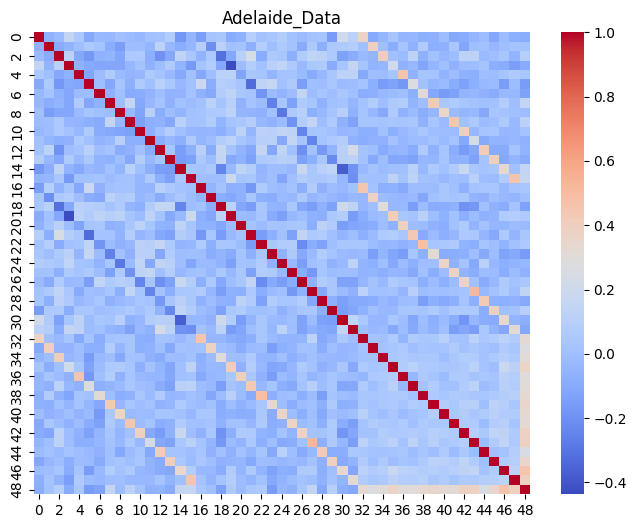

Perth_Data (72000, 49)


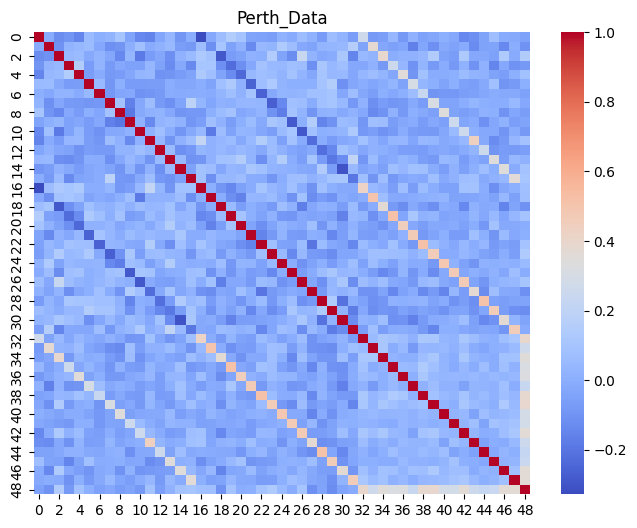

Sydney_Data (72000, 49)


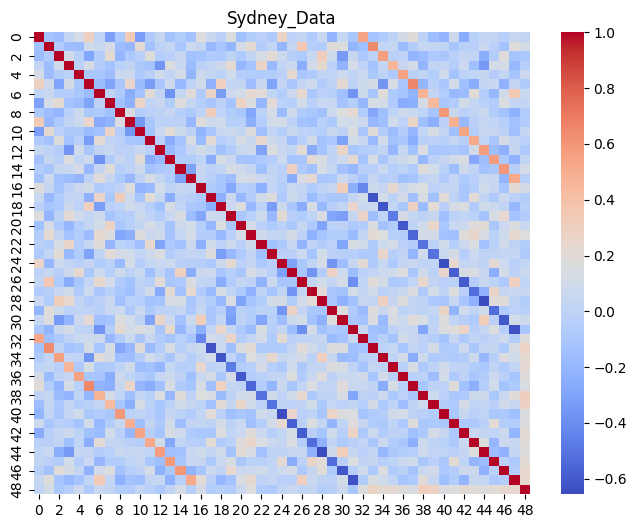

Tasmania_Data (72000, 49)


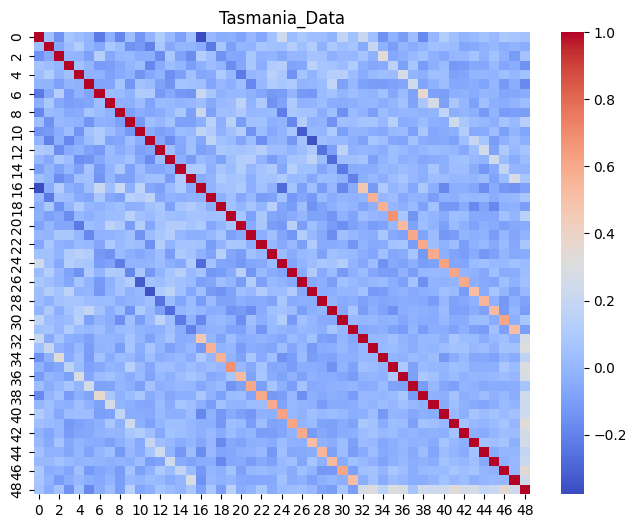

In [ ]:
for ds in [
    "Adelaide_Data",
    "Perth_Data",
    "Sydney_Data",
    "Tasmania_Data",
]:
  df = pd.read_csv(f"WECs_DataSet/{ds}.csv", header=None)

  print(ds, df.shape)

  corr = df.corr()

  plt.figure(figsize=(8,6))
  sns.heatmap(corr, annot=False, cmap="coolwarm")
  plt.title(ds)
  plt.show()

Takeaways:

* X and Y layout coordinates (columns 0-31) show moderate positive and negative correlations, reflecting how moving one WEC often forces coordinated shifts in others.

* Clear diagonal patterns indicate structured relationships among layout variables, not random noise.



There is also one interesting property of data:

In [ ]:
for ds in [
    # "Adelaide_Data",
    # "Perth_Data",
    "Sydney_Data",
    "Tasmania_Data",
]:
  df = pd.read_csv(f"WECs_DataSet/{ds}.csv", header=None)

  print(
      ds, (df[np.arange(32, 48)].sum(axis=1) - df[48]).max()
  )

Sydney_Data 0.0008999998681247234
Tasmania_Data 0.0008000005036592484


The final column (total power readout) is (approximately) the sum of columns 32-48.

We will select positions (columns 0-32) as our features and total power output (col 48) as our target.

Let's visualize the distributions of column values.

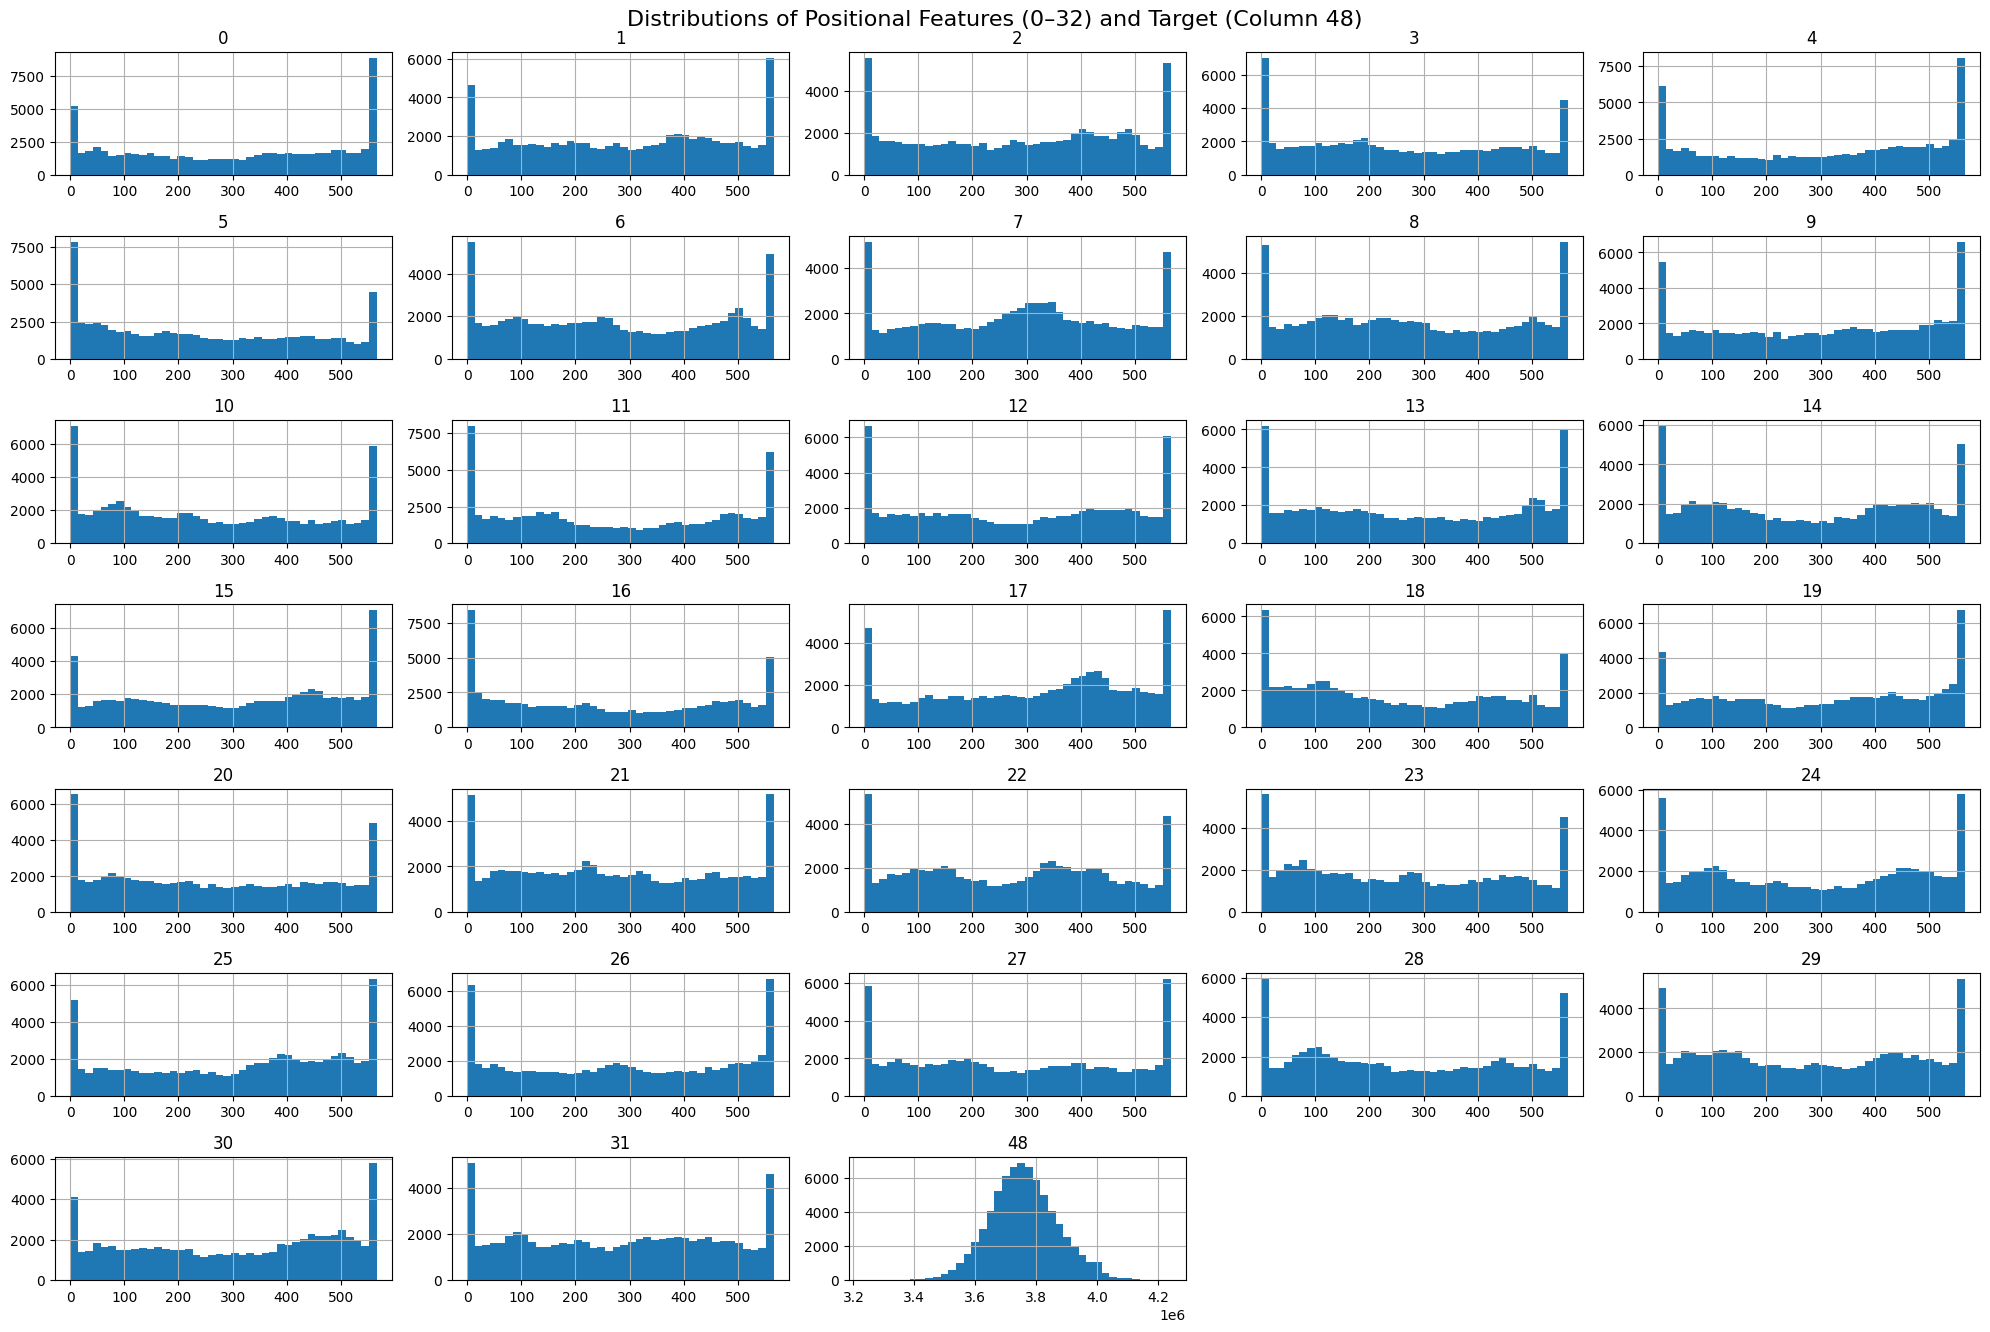

In [ ]:
feature_cols = list(range(0, 32))
target_col = 48

cols_to_plot = feature_cols + [target_col]

df.iloc[:, cols_to_plot].hist(
    bins=40,
    figsize=(20, 15),
    layout=(8, 5),
)

plt.suptitle("Distributions of Positional Features (0–32) and Target (Column 48)", fontsize=16)
plt.tight_layout()
plt.show()

All feature columns have spikes at the minimal / maximal values (0 / 566), but follow a distribution that is close to uniform otherwise.

We interpret samples in which any coordinate equals 0 or 566 as boundary or invalid layouts. These boundary cases form dense spikes in feature histograms and do not reflect realistic layouts, so could be problematic.

Let's count in how many rows there are no such problems:

In [ ]:
valid = (df.iloc[:, 0:32] > 0) & (df.iloc[:, 0:32] < 566)
df_clean = df[valid.all(axis=1)]

len(df), len(df_clean)

(72000, 14294)

However, removing such values would remove 80% of the dataset. We will keep these datapoints.

## Modeling



Let's remind what is our dataset name.

In [ ]:
ds, np.array(feature_cols), target_col

('Tasmania_Data',
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 48)

We will split our data randomly and keep 20% of data as test.

In [ ]:
X = df.iloc[:, feature_cols].values
y = df.iloc[:, target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

Let's now define the pipeline: data scaler for the models that need it and a regressor (we will check multple models):

In [ ]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Ridge())   # placeholder, will be overridden in param_grid
])

We will select the best model according to negative MAPE (Mean Absolute Percentage Error):


In [ ]:
mape_scorer = make_scorer(
    mean_absolute_percentage_error,
    greater_is_better=False
)

We will now define the model params to grid-search over. We will try two model classes:

* Ridge Regression – a simple linear baseline model with L2 regularization.

* HistGradientBoostingRegressor – a fast, off-the-shelf nonlinear boosting model for structured tabular data.

In [ ]:
param_grid = [
    # Ridge (linear model)
    # {
    #     "regressor": [Ridge()],
    #     "regressor__alpha": [0.1, 1.0, 10.0],
    # },
    # Fast hist-gradient boost with early stopping
    # {
    #     "regressor": [HistGradientBoostingRegressor(
    #         early_stopping=True,
    #         validation_fraction=0.1,
    #         n_iter_no_change=20,
    #         max_iter=500,
    #         random_state=0
    #     )],
    #     "regressor__max_depth": [6, 8, 10],
    #     "regressor__learning_rate": [0.05, 0.1],
    # },
    # XGBoost
    {
        "regressor": [XGBRegressor(
            n_estimators=500,
            objective="reg:squarederror",
            random_state=0,
            n_jobs=-1,
        )],
        "regressor__max_depth": [8], #[4, 6, 8],
        "regressor__learning_rate": [0.1], #[0.05, 0.1],
    },
    # # LightGBM
    # {
    #     "regressor": [LGBMRegressor(
    #         n_estimators=500,
    #         objective="regression",
    #         random_state=0,
    #         n_jobs=-1,
    #     )],
    #     "regressor__max_depth": [-1, 6, 8],
    #     "regressor__learning_rate": [0.05, 0.1],
    # },
]



We will perform a 5-fold cross-validation of models:

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=mape_scorer,   # select best by MAPE
    cv=cv,
    n_jobs=-1,
    verbose=3
)

We will now perform the grid-search and find the best model:

In [ ]:
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV MAPE: {:.3f}%".format(-100 * grid.best_score_))

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best params: {'regressor': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...), 'regressor__learning_rate': 0.1, 'regressor__max_depth': 8}
Best CV MAPE: 0.997%


Time to evaluate the final performance of the model on the unseen test data!

In [ ]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("\nTest set performance:")
print(f"MAPE = {mape:.2f}%")
print(f"R^2  = {r2:.4f}")
print(f"MSE = {mse:.2f}")
print(f"MSE = {np.sqrt(mse):.2f}")



Test set performance:
MAPE = 0.99%
R^2  = 0.8087
MSE = 2350582410.33
MSE = 48482.81


The final XGBRegressor model achieves excellent predictive accuracy on unseen data, with only ~0.99% MAPE and R$^2$≈0.807, indicating that total absorbed power can be reliably predicted from WEC layout coordinates.

Text(0, 0.5, 'Predicted values')

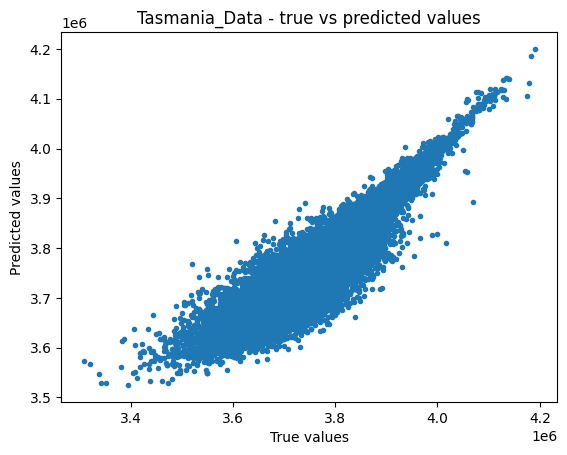

In [ ]:
plt.scatter(y_test, y_pred, marker=".")
plt.title(f"{ds} - true vs predicted values")
plt.xlabel("True values")
plt.ylabel("Predicted values")